# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

# Carregamento da base e pré-processamento

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [18]:
df = pd.read_csv('Mall_Customers (1).csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [19]:
#Verificação do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [20]:
#Verificação de dados ausentes
(df.isnull().sum()) /len(df) * 100

CustomerID                0.0
Gender                    0.0
Age                       0.0
Annual Income (k$)        0.0
Spending Score (1-100)    0.0
dtype: float64

In [21]:
#Exclusão de colunas desnecessárias para k means
df.drop(['CustomerID', 'Gender'], axis=1, inplace=True)

In [22]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


# Distribuição dos dados

In [21]:
#Verificando comportamento dos dados
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Os valores das médias e medianas estão bem aproximados nas colunas. O valor máximo na coluna "Annul Income" está bem distante comparado com as outras colunas, isso pode se da devido a presença de Outliers, ou apenas a distribuição dos dados. 

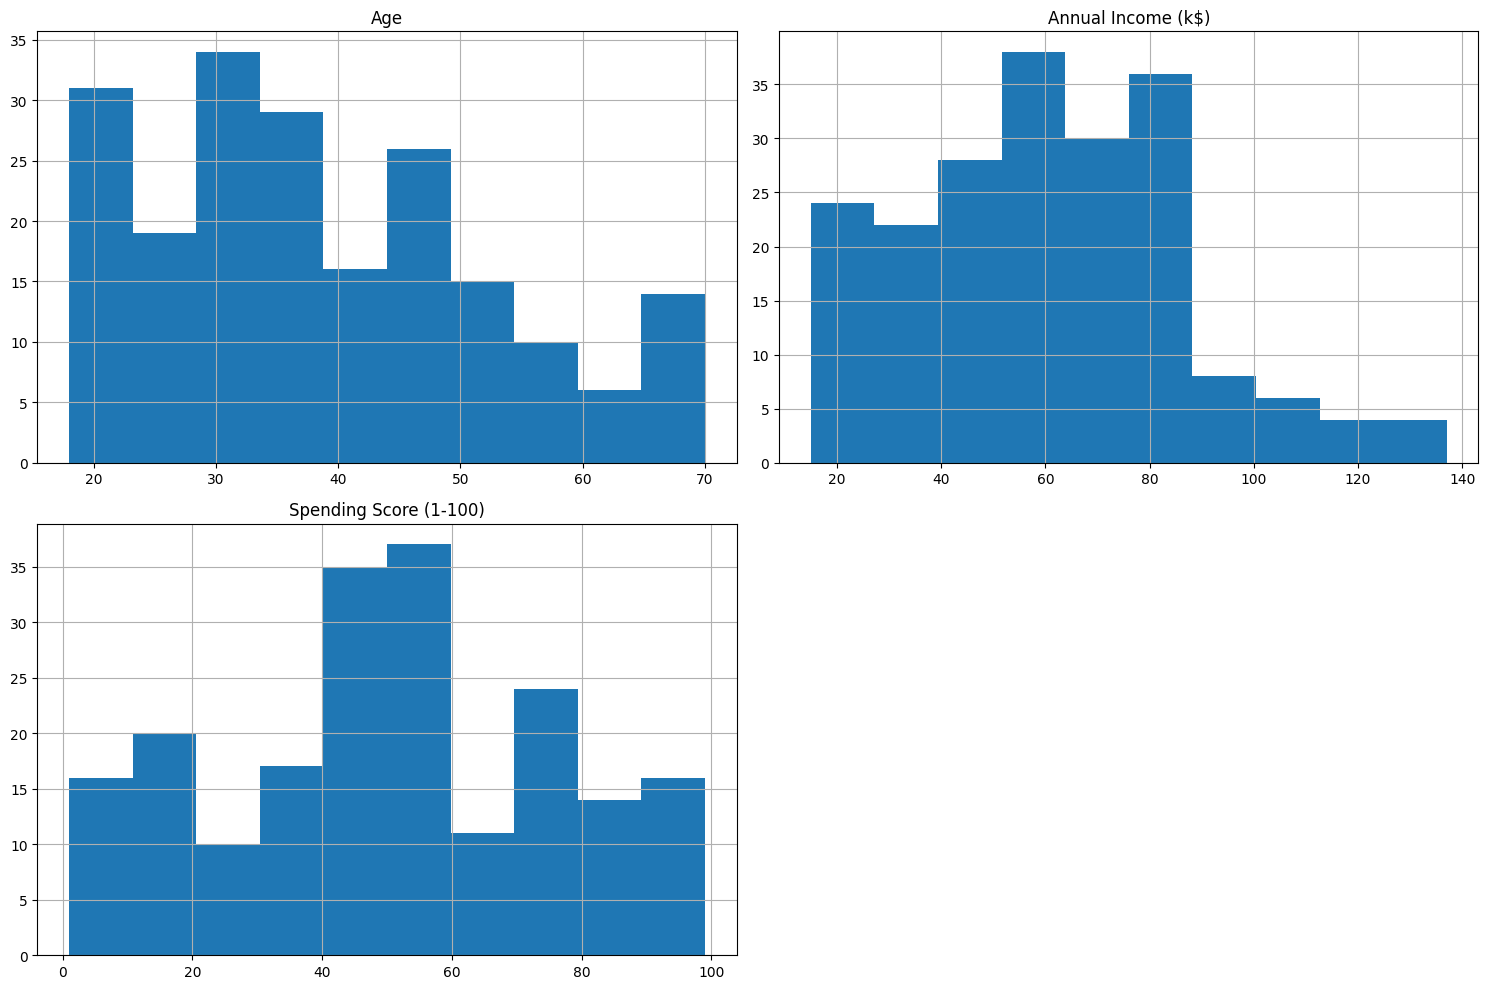

In [11]:
#Verificando a distribuição das variáveis
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

A maioria das variáveis possuem os dados com o pico de aglomeração mais a esquerda, com excessão apenas de 'spending score' que aparenta ter uma distribuição mais normal.

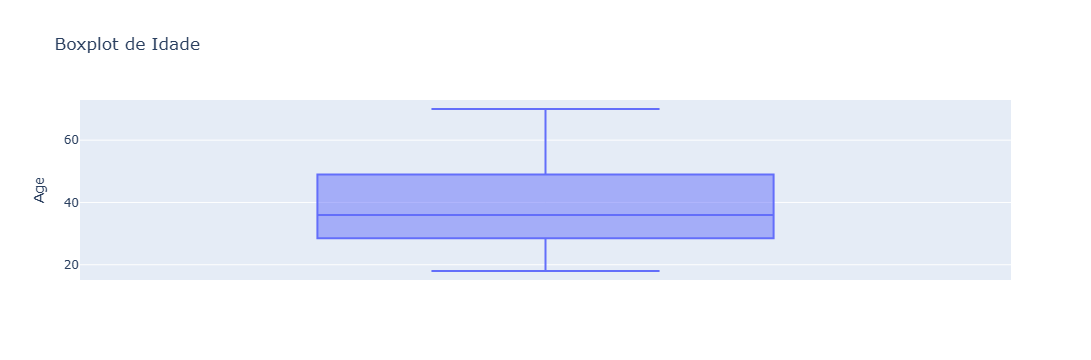

In [14]:
#Verificação da presença de Ouliers
fig = px.box(df, y='Age', title='Boxplot de Idade')
fig.show()

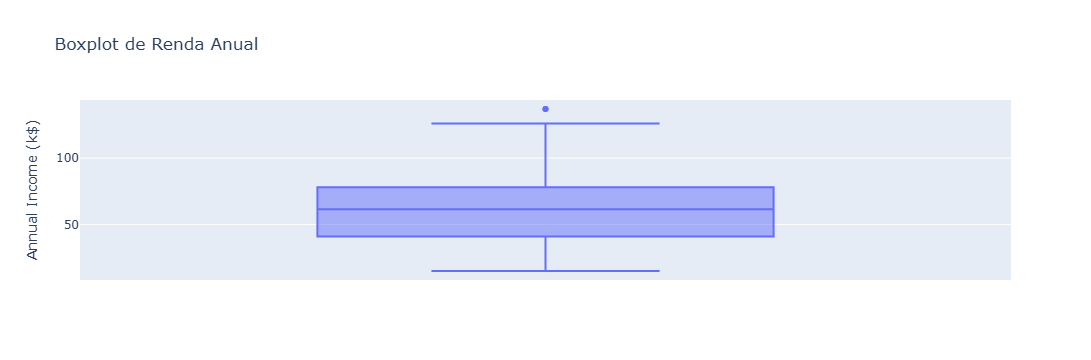

In [15]:
fig = px.box(df, y='Annual Income (k$)', title='Boxplot de Renda Anual')
fig.show()

In [19]:
#Cruzamento de variáveis para observar comportamento do Outlier acima
df.sort_values('Annual Income (k$)', ascending=False)[
    ['Annual Income (k$)', 'Age', 'Spending Score (1-100)']
].head(10)

,Annual Income (k$),Age,Spending Score (1-100)
199,137,30,83
198,137,32,18
197,126,32,74
196,126,45,28
195,120,35,79
194,120,47,16
193,113,38,91
192,113,33,8
188,103,41,17
189,103,36,85


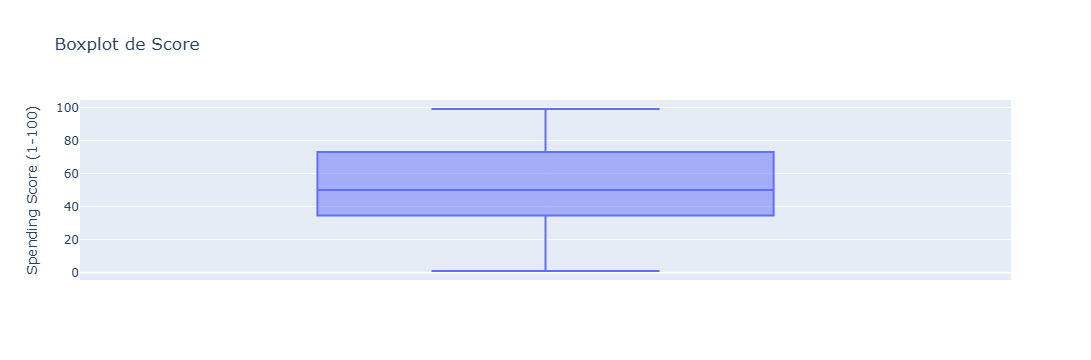

In [16]:
fig = px.box(df, y='Spending Score (1-100)', title='Boxplot de Score')
fig.show()

A única coluna que apresentou Outlier foi 'Annual Income', mas pelo observado é um dado real porém raro.

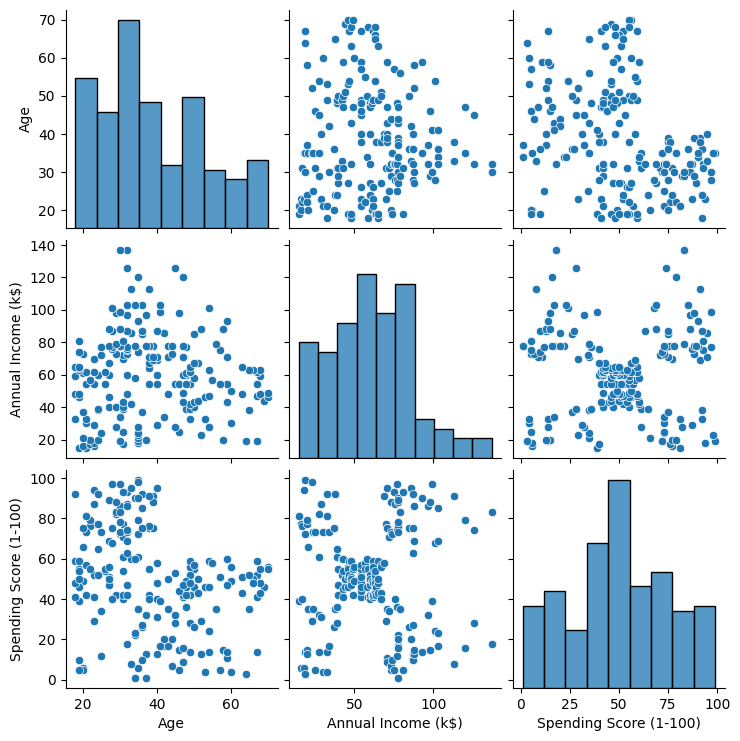

In [31]:
#Distribuição das variáveis entre si
sns.pairplot(df)

# Padronização dos dados

In [23]:
#Inicialização de Stantard
sc = StandardScaler()
df_padron = sc.fit_transform(df)

# Modelagem: Aplicando K-means na base

In [32]:
kmeans = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans.fit(df_padron)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [33]:
centroides = kmeans.cluster_centers_
centroides

array([[-0.93381128, -0.67979753,  0.1338202 ],
       [-0.43033758,  1.02223317,  1.15593564],
       [ 0.8916814 ,  0.04741398, -0.62080368]])

In [34]:
#Despadronização dos dados para aplicar gráfico de dispersão
centroides_padron = kmeans.cluster_centers_ # Centroides padronizados retornados pelo k-means

#Inverter a padronização para obter os centroides originais
centroides_originais = sc.inverse_transform(centroides_padron)
centroides_originais

array([[25.83823529, 42.75      , 53.64705882],
       [32.85365854, 87.34146341, 79.97560976],
       [51.27472527, 61.8021978 , 34.20879121]])

# Gráficos para visualização e Avaliação do modelo

In [35]:
#Criando labels para agrupamentos
labels = kmeans.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0,
       0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       1, 1], dtype=int32)

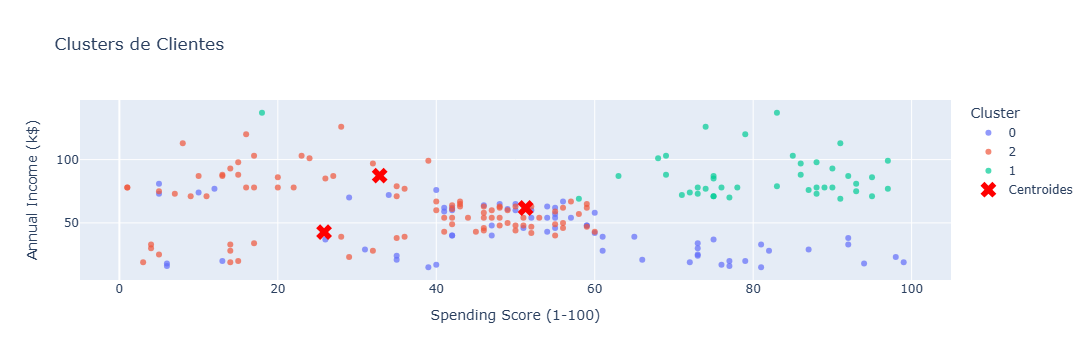

In [44]:
# Criando um df com os dados originais e  rótulos de cluster
pen_clusters = pd.DataFrame({
    'Spending Score (1-100)': df['Spending Score (1-100)'],
    'Annual Income (k$)': df['Annual Income (k$)'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(pen_clusters, x='Spending Score (1-100)', y='Annual Income (k$)', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Clientes')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Spending Score (1-100)', yaxis_title='Annual Income (k$)',
                  legend_title='Cluster')
fig.show()

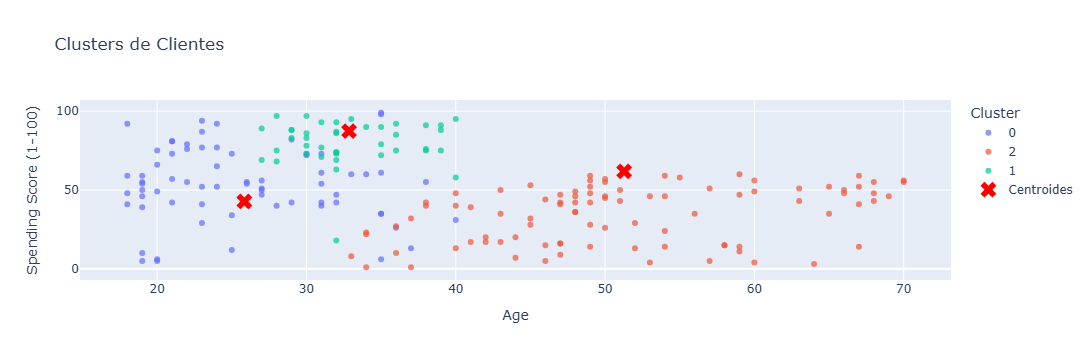

In [45]:
# Criando um df com os dados originais e  rótulos de cluster
pen_clusters = pd.DataFrame({
    'Age': df['Age'],
    'Spending Score (1-100)': df['Spending Score (1-100)'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(pen_clusters, x='Age', y='Spending Score (1-100)', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Clientes')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Age', yaxis_title='Spending Score (1-100)',
                  legend_title='Cluster')
fig.show()

In [45]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [40]:
df['cluster'] = labels

In [41]:
media_cluster = df.groupby('cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

In [42]:
media_cluster

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,25.838235,42.750000,53.647059
1,32.853659,87.341463,79.975610
2,51.274725,61.802198,34.208791


* O cluster '0' tem pessoas com a média de idade de 25 anos, que tem a renda média anual de 42 mil, com a pontuação de 53, consumo médio.

* O cluster '1' tem pessoas com a média de idade de 32 anos, com renda anula média de 87 mil, e pontuação de 79, alto consumo.
* O cluster '2' tem pessoas com a média de idade de 51 anos, com a renda anual em média de 61 mil, e a pontuação de 34, consumo baixo.